<a href="https://colab.research.google.com/github/mariatorresd-star/PC1-YELLOW_TAXI_NYC_CASE/blob/main/PC1_BD_y_DA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚕 Caso 2: Movilidad urbana y demanda de transporte
Dataset base:
NYC Yellow Taxi Trips – NYC Open Data / Kaggle

Enriquecimiento sugerido:
Datos del clima (OpenWeatherMap API), eventos públicos (NYC Events API), precios de Uber/Lyft scrapeados o públicos.

Pregunta de negocio: ¿Cómo varían la demanda y los precios de transporte según la hora, el
clima y los eventos en la ciudad?

Valor para la empresa: Permite a plataformas de movilidad optimizar la distribución de
conductores y la fijación dinámica de precios.

In [ ]:
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-03.parquet'
df_taxis = pd.read_parquet(URL)

print(f'Dataset cargado')
print(f'Total de filas: {len(df_taxis):,}')
print(f'Total de columnas: {len(df_taxis.columns)}')

Dataset cargado
Total de filas: 3,627,882
Total de columnas: 19


In [ ]:
print('Encabezado del dataset:')
df_taxis.head()

Encabezado del dataset:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-03-01 00:13:08,2022-03-01 00:24:35,1.0,2.40,1.0,N,90,209,2,10.0,3.0,0.5,0.00,0.0,0.3,13.80,2.5,0.00
1,1,2022-03-01 00:47:52,2022-03-01 01:00:08,1.0,2.20,1.0,N,148,234,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,0.00
2,2,2022-03-01 00:02:46,2022-03-01 00:46:43,1.0,19.78,2.0,N,132,249,1,52.0,0.0,0.5,11.06,0.0,0.3,67.61,2.5,1.25
3,2,2022-03-01 00:52:43,2022-03-01 01:03:40,2.0,2.94,1.0,N,211,66,1,11.0,0.5,0.5,4.44,0.0,0.3,19.24,2.5,0.00
4,2,2022-03-01 00:15:35,2022-03-01 00:34:13,1.0,8.57,1.0,N,138,197,1,25.0,0.5,0.5,5.51,0.0,0.3,33.06,0.0,1.25


In [ ]:
print('Estructura del dataset:')
print(f'\nColumnas disponibles:')
for col in df_taxis.columns:
    print(f'  → {col} ({df_taxis[col].dtype})')

Estructura del dataset:

Columnas disponibles:
  → VendorID (int64)
  → tpep_pickup_datetime (datetime64[us])
  → tpep_dropoff_datetime (datetime64[us])
  → passenger_count (float64)
  → trip_distance (float64)
  → RatecodeID (float64)
  → store_and_fwd_flag (object)
  → PULocationID (int64)
  → DOLocationID (int64)
  → payment_type (int64)
  → fare_amount (float64)
  → extra (float64)
  → mta_tax (float64)
  → tip_amount (float64)
  → tolls_amount (float64)
  → improvement_surcharge (float64)
  → total_amount (float64)
  → congestion_surcharge (float64)
  → airport_fee (float64)


Valores nulos por columna — Dataset Taxis:


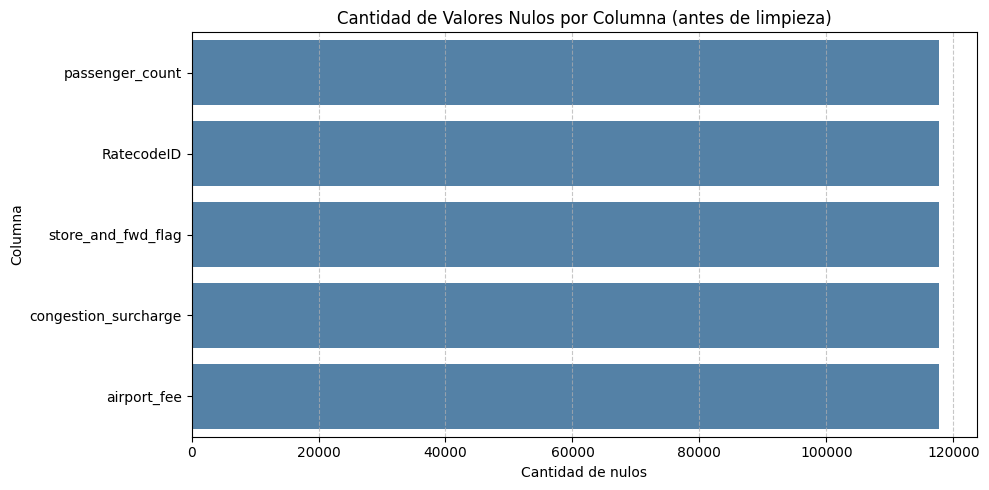


Total de filas con al menos un nulo: 117,814


In [ ]:
# ── Visualización de valores nulos ──────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

print("Valores nulos por columna — Dataset Taxis:")
nulos = df_taxis.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=nulos.values, y=nulos.index, color='steelblue')
plt.title('Cantidad de Valores Nulos por Columna (antes de limpieza)')
plt.xlabel('Cantidad de nulos')
plt.ylabel('Columna')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nTotal de filas con al menos un nulo: {df_taxis.isnull().any(axis=1).sum():,}")

In [ ]:

df_taxis = df_taxis.drop_duplicates()

df_taxis['tpep_pickup_datetime'] = pd.to_datetime(df_taxis['tpep_pickup_datetime'])
df_taxis['tpep_dropoff_datetime'] = pd.to_datetime(df_taxis['tpep_dropoff_datetime'])

df_taxis = df_taxis[
    (df_taxis['passenger_count'] > 0) &
    (df_taxis['trip_distance'] > 0) &
    (df_taxis['fare_amount'] > 0)
]

df_taxis = df_taxis[df_taxis['tpep_pickup_datetime'].dt.month == 3]
df_taxis = df_taxis[df_taxis['tpep_pickup_datetime'].dt.year == 2022]

df_taxis['congestion_surcharge'] = df_taxis['congestion_surcharge'].fillna(0)

print("Limpieza de Taxis completada.")

Limpieza de Taxis completada.


In [ ]:
#enriquecimiento

url_eventos = "https://data.cityofnewyork.us/resource/bkfu-528j.csv?$where=start_date_time%20between%20'2022-03-01T00:00:00'%20and%20'2022-03-31T23:59:59'&$limit=50000"
df_eventos = pd.read_csv(url_eventos)
df_eventos.head()

,event_id,event_name,start_date_time,end_date_time,event_agency,event_type,event_borough,event_location,event_street_side,street_closure_type,community_board,police_precinct
0,610373,"Dana Discovery Lawn Winter Closure Oct. 31, 20...",2022-03-01T00:00:00.000,2022-03-01T23:59:00.000,Parks Department,Special Event,Manhattan,Central Park: Dana Discovery Center Lawn,NaN,NaN,"64,","22,"
1,615693,Lawn Closure of Oval lawn,2022-03-01T00:00:00.000,2022-03-01T23:00:00.000,Parks Department,Special Event,Manhattan,Madison Square Park: Oval Lawn,NaN,NaN,"5,","13,"
2,610382,"East Green Lawn Winter Closure Nov. 29, 2021 -...",2022-03-01T00:00:00.000,2022-03-01T23:59:00.000,Parks Department,Special Event,Manhattan,Central Park: East 72nd Street Playground Lawns,NaN,NaN,"8,","19,"
3,615690,Lawn Closure of Magnolia Lawn,2022-03-01T00:00:00.000,2022-03-01T23:00:00.000,Parks Department,Special Event,Manhattan,Madison Square Park: Magnolia Lawn,NaN,NaN,"5,","13,"
4,610487,"Reservoir North Lawn Winter Closure Dec.2, 202...",2022-03-01T00:00:00.000,2022-03-01T23:59:00.000,Parks Department,Special Event,Manhattan,"Central Park: North Reservoir Landscape A ,Cen...",NaN,NaN,"64,","22,"


In [ ]:

df_eventos.columns = df_eventos.columns.str.strip()

df_eventos['start_date_time'] = pd.to_datetime(df_eventos['start_date_time'])
df_eventos['end_date_time'] = pd.to_datetime(df_eventos['end_date_time'])

df_eventos = df_eventos.dropna(subset=['event_name'])
df_eventos['event_location'] = df_eventos['event_location'].fillna('Location Not Specified')

df_eventos['event_type'] = df_eventos['event_type'].str.capitalize()

print("Limpieza de Eventos completada.")

Limpieza de Eventos completada.


In [ ]:
df_taxis['hora_pickup'] = df_taxis['tpep_pickup_datetime'].dt.hour
df_taxis['dia_semana'] = df_taxis['tpep_pickup_datetime'].dt.day_name()

df_taxis['duracion_minutos'] = (df_taxis['tpep_dropoff_datetime'] - df_taxis['tpep_pickup_datetime']).dt.total_seconds() / 60

df_taxis = df_taxis[(df_taxis['duracion_minutos'] > 1) & (df_taxis['duracion_minutos'] < 180)]

df_eventos['dia_evento'] = df_eventos['start_date_time'].dt.date

# Visualización 1 — Histograma por hora

Histograma de la hora de recogida (Demanda por hora)


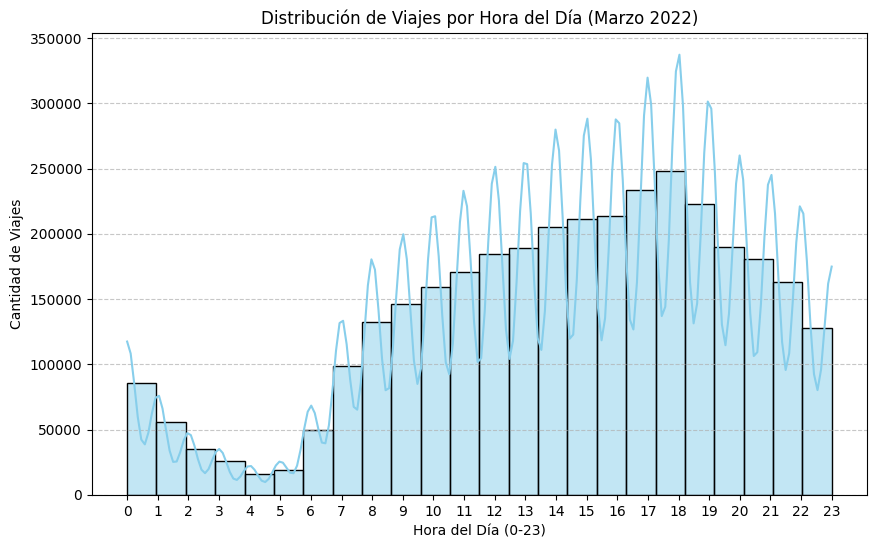

In [ ]:
print("Histograma de la hora de recogida (Demanda por hora)")
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_taxis['hora_pickup'], bins=24, kde=True, color='skyblue')
plt.title('Distribución de Viajes por Hora del Día (Marzo 2022)')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Cantidad de Viajes')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretación:**

La demanda de taxis alcanza su punto más bajo entre las 3am y 6am,
y se incrementa progresivamente hasta alcanzar el pico entre las 18h y 20h. Esto indica que las plataformas de movilidad deben concentrar su flota disponible en el horario vespertino para cubrir la salida laboral, y reducir operaciones en madrugada para optimizar costos.

# Visualización 2 — Boxplot de tarifas

Boxplot de la Tarifa (Detección de Outliers)


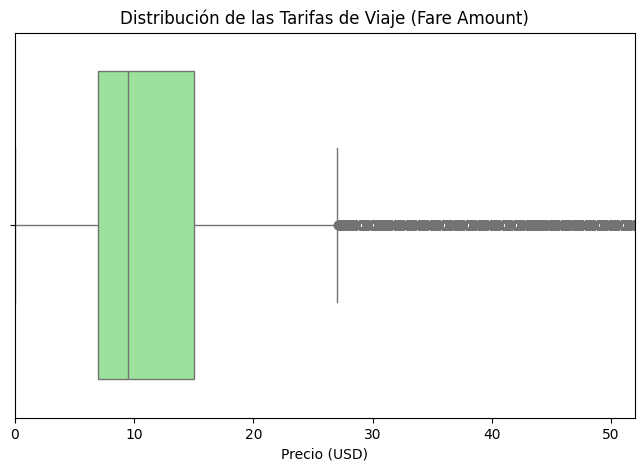

Media de tarifa:         $13.72
25% de viajes por debajo de: $7.00
50% de viajes por debajo de: $9.50
75% de viajes por debajo de: $15.00
99% de viajes por debajo de: $52.00


In [ ]:
print("Boxplot de la Tarifa (Detección de Outliers)")
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_taxis['fare_amount'], color='lightgreen')
plt.title('Distribución de las Tarifas de Viaje (Fare Amount)')
plt.xlabel('Precio (USD)')
plt.xlim(0, df_taxis['fare_amount'].quantile(0.99))
plt.show()

# Estadísticas reales de la tarifa
q25 = df_taxis['fare_amount'].quantile(0.25)
q50 = df_taxis['fare_amount'].quantile(0.50)
q75 = df_taxis['fare_amount'].quantile(0.75)
q99 = df_taxis['fare_amount'].quantile(0.99)
media = df_taxis['fare_amount'].mean()

print(f"Media de tarifa:         ${media:.2f}")
print(f"25% de viajes por debajo de: ${q25:.2f}")
print(f"50% de viajes por debajo de: ${q50:.2f}")
print(f"75% de viajes por debajo de: ${q75:.2f}")
print(f"99% de viajes por debajo de: ${q99:.2f}")

**Interpretación:**

La tarifa promedio de los viajes en taxi durante marzo 2022 es de 13.72 USD. El 50% de los viajes cuesta menos de 9.50 USD, lo que indica que la mayoría son trayectos cortos, probablemente dentro de Manhattan. El 75% de los viajes se encuentra por debajo de 15.00 USD, confirmando que los viajes de precio moderado dominan la operación diaria.

Sin embargo, existe una cola larga de outliers que llega hasta 52.00 USD en el percentil 99, los cuales corresponden probablemente a viajes hacia los aeropuertos JFK o LaGuardia. Para una plataforma de movilidad, esto sugiere que la estrategia de precios debe diferenciarse entre viajes urbanos cortos (tarifa base de 9.50 USD) y viajes de largo recorrido donde el precio puede superar los 30 USD.

# Visualización 3 — Barras de tipos de eventos

Gráfico de Barras de Tipos de Eventos


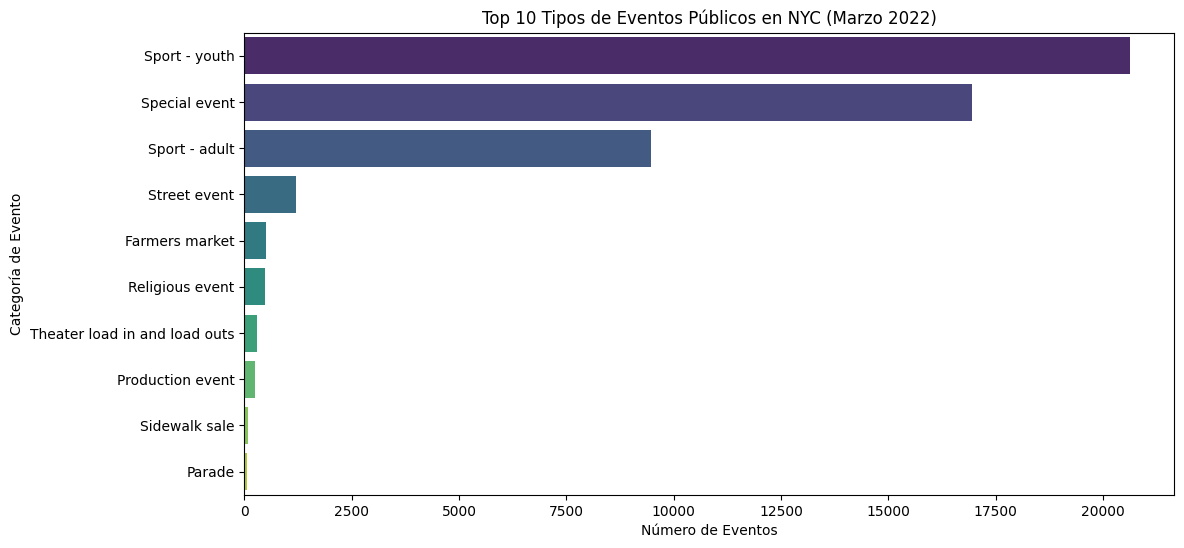

In [ ]:
print("Gráfico de Barras de Tipos de Eventos")
plt.figure(figsize=(12, 6))
event_counts = df_eventos['event_type'].value_counts().head(10) # Top 10 tipos
sns.barplot(x=event_counts.values, y=event_counts.index, palette='viridis')
plt.title('Top 10 Tipos de Eventos Públicos en NYC (Marzo 2022)')
plt.xlabel('Número de Eventos')
plt.ylabel('Categoría de Evento')
plt.show()

**Interpretación:**

Los eventos deportivos juveniles y especiales dominan el calendario público de NYC en marzo 2022, superando los 15,000 y 17,000 registros respectivamente. Esto sugiere que los fines de semana con competencias deportivas son momentos clave donde la demanda de transporte hacia parques y estadios podría incrementarse significativamente.

# Visualización 4 — Heatmap de correlaciones

Mapa de Calor de Correlación


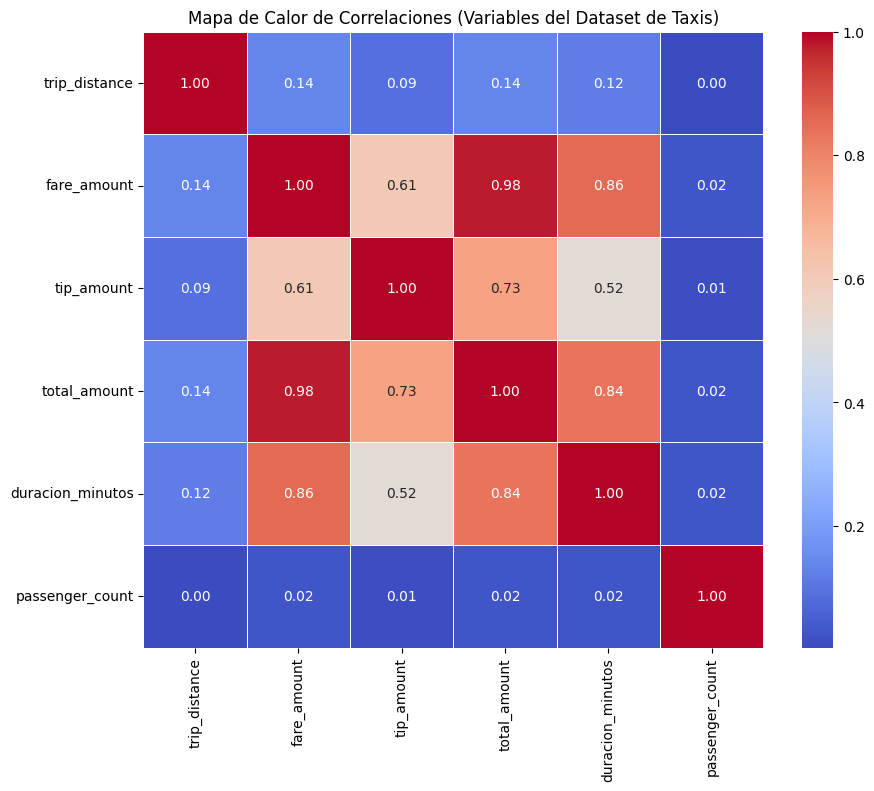

In [ ]:
print("Mapa de Calor de Correlación")
plt.figure(figsize=(10, 8))
cols_interes = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'duracion_minutos', 'passenger_count']
correlation = df_taxis[cols_interes].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones (Variables del Dataset de Taxis)')
plt.show()

**Interpretación:**

Existe una correlación muy alta (0.98) entre *fare_amount* y *total_amount*, lo cual es esperado. Más relevante es la correlación moderada (0.86) entre *duracion_minutos* y *fare_amount*, lo que confirma que el tiempo de viaje es el principal determinante del precio. Sorprendentemente, *trip_distance* tiene una correlación baja (0.14) con la tarifa, lo que podría explicarse por la congestión vehicular en Manhattan.

# Visualización 5 — Serie de tiempo diaria

Gráfico de Líneas: Serie de Tiempo Mensual


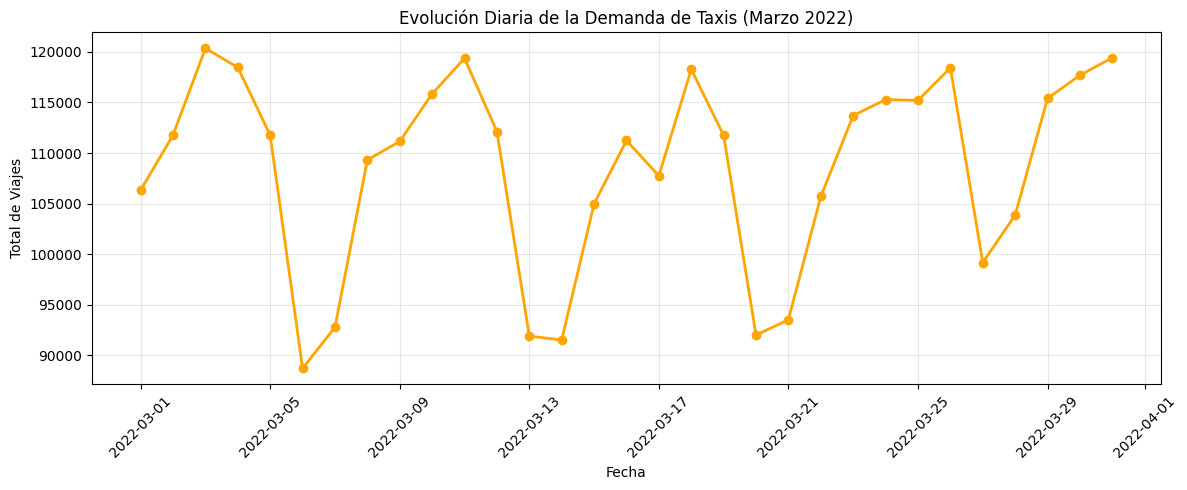

In [ ]:
print("Gráfico de Líneas: Serie de Tiempo Mensual")
viajes_por_dia = df_taxis.groupby(df_taxis['tpep_pickup_datetime'].dt.date).size()

plt.figure(figsize=(12, 5))
viajes_por_dia.plot(kind='line', marker='o', color='orange', linewidth=2)
plt.title('Evolución Diaria de la Demanda de Taxis (Marzo 2022)')
plt.xlabel('Fecha')
plt.ylabel('Total de Viajes')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación:**

La demanda diaria oscila entre 90,000 y 120,000 viajes durante marzo 2022, mostrando caídas pronunciadas cada 7 días que coinciden con los domingos, cuando la actividad laboral es mínima. Los picos más altos ocurren los martes y jueves. Este patrón semanal es clave para que los operadores planifiquen la disponibilidad de conductores con
anticipación.

# Visualización 6 — Correlación taxis vs eventos (Pearson -0.38)

In [ ]:
print(f"Registros en Taxis: {len(df_taxis)}")
print(f"Registros en Eventos: {len(df_eventos)}")

if len(df_eventos) > 0:
    print("Muestra de fechas de Eventos:", df_eventos['start_date_time'].head(2).values)
if len(df_taxis) > 0:
    print("Muestra de fechas de Taxis:", df_taxis['tpep_pickup_datetime'].head(2).values)

Registros en Taxis: 3364762
Registros en Eventos: 50000
Muestra de fechas de Eventos: ['2022-03-01T00:00:00.000000000' '2022-03-01T00:00:00.000000000']
Muestra de fechas de Taxis: ['2022-03-01T00:13:08.000000' '2022-03-01T00:47:52.000000']


Correlacion Inicial Taxis-Eventos


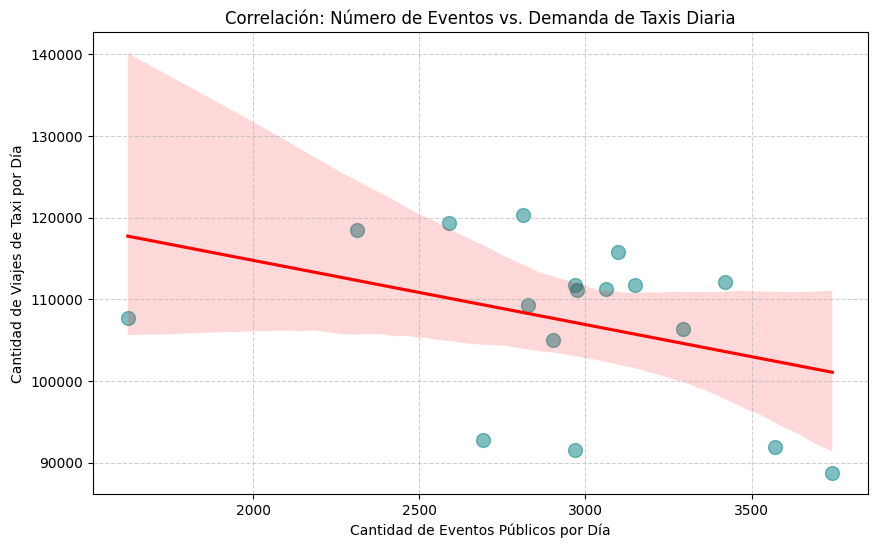

Número de días analizados: 17
El coeficiente de correlación de Pearson es: -0.38


In [ ]:
print("Correlacion Inicial Taxis-Eventos")
df_taxis['fecha_clean'] = pd.to_datetime(df_taxis['tpep_pickup_datetime']).dt.date
df_eventos['fecha_clean'] = pd.to_datetime(df_eventos['start_date_time']).dt.date

viajes_diarios = df_taxis.groupby('fecha_clean').size().reset_index()
viajes_diarios.columns = ['fecha_clean', 'cantidad_viajes']

eventos_diarios = df_eventos.groupby('fecha_clean').size().reset_index()
eventos_diarios.columns = ['fecha_clean', 'cantidad_eventos']

df_correlacion = pd.merge(viajes_diarios, eventos_diarios, on='fecha_clean', how='inner')

if df_correlacion.empty:
    print("Error: No se encontraron coincidencias de fechas entre ambos datasets.")
elif len(df_correlacion) < 2:
    print("Error: No hay suficientes puntos de datos para calcular la correlación.")
else:
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_correlacion, x='cantidad_eventos', y='cantidad_viajes',
                scatter_kws={'s':100, 'alpha':0.5, 'color':'teal'},
                line_kws={'color':'red'})

    plt.title('Correlación: Número de Eventos vs. Demanda de Taxis Diaria')
    plt.xlabel('Cantidad de Eventos Públicos por Día')
    plt.ylabel('Cantidad de Viajes de Taxi por Día')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    coef = df_correlacion['cantidad_eventos'].corr(df_correlacion['cantidad_viajes'])
    print(f"Número de días analizados: {len(df_correlacion)}")
    print(f"El coeficiente de correlación de Pearson es: {coef:.2f}")

**Interpretación**

El coeficiente de Pearson de -0.38 indica una correlación negativa moderada entre la cantidad de eventos públicos y los viajes de taxi por día. Este resultado contraintuitivo podría explicarse porque muchos eventos del dataset son deportivos en parques, a los que los asistentes llegan caminando o en metro. En la Etapa 2 se profundizará este análisis filtrando por tipo de evento y zona geográfica específica.